In [1]:
import sys
sys.path.insert(0, "/home/winnieyangwn/rllm")
import importlib

import analysis.utils.eval_utils as eval_utils 

importlib.reload(eval_utils)
from analysis.utils.eval_utils import *

/storage/home/winnieyangwn/miniforge3/envs/aira-dojo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Step 9 Validation - NEW agent loop (job 5924685)
data_path = "/checkpoint/maui_sft/winnieyangwn/rllm/step9_validation/new/mlsp-2013-birds.jsonl"

In [3]:
import pandas as pd

df = pd.read_json(data_path, lines=True)

Found 52 rollouts matching valid criteria
Found 0 rollouts matching invalid criteria (excluding infra errors)
Found 11 rollouts with infrastructure errors

Infrastructure Error Breakdown:
   Infrastructure Error Category  Count  Percentage
Infrastructure: Model Call Error     11       100.0


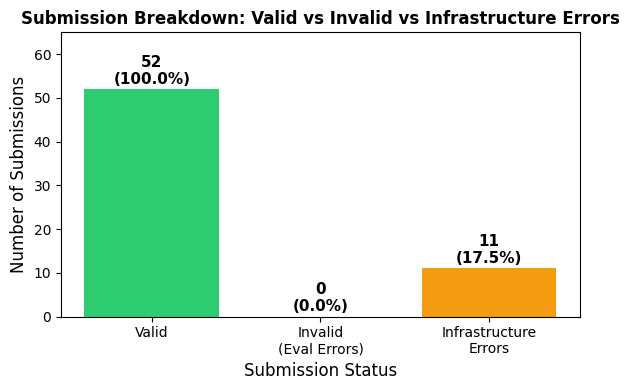

In [4]:
valid_df, invalid_df, infra_df = plot_submission_validity_breakdown(df)

In [5]:
# Test process_df function
importlib.reload(eval_utils)
from analysis.utils.eval_utils import process_df

df_processed, df_task = process_df(df, Ks=[1, 4, 8, 16, 24, 32, 40, 48, 56, 64])

print("=== df_processed (rollout-level) ===")
print(f"Shape: {df_processed.shape}")


print("\n\n=== df_task (task-level) ===")
print(f"Shape: {df_task.shape}")
display(df_task)

=== df_processed (rollout-level) ===
Shape: (63, 17)


=== df_task (task-level) ===
Shape: (1, 28)


,n_rollouts,pass@1,pass@4,pass@8,pass@16,pass@24,pass@32,pass@40,pass@48,pass@56,...,valid_pass@48,valid_pass@56,valid_pass@64,any_medal_rate,gold_medal_rate,silver_medal_rate,bronze_medal_rate,gold_threshold,silver_threshold,bronze_threshold
task_name,,,,,,,,,,,,,,,,,,,,,
mlsp-2013-birds,63,0.313933,0.391961,0.405722,0.407392,0.407407,0.407407,0.407407,0.407407,0.407407,...,1.0,1.0,NaN,0.0,0.0,0.0,0.0,0.907407,0.808642,0.611111


In [6]:
get_summary_stats(df)

{'total': 63,
 'valid_submissions': 63,
 'valid_rate': np.float64(100.0),
 'passed': 63,
 'pass_rate': np.float64(100.0),
 'avg_percentile': np.float64(0.31393298059964686),
 'min_percentile': np.float64(0.17283950617283902),
 'max_percentile': np.float64(0.40740740740740705),
 'avg_score': np.float64(0.7749522222222224)}

In [7]:
df.shape

(63, 9)

Using pre-computed pass@k for 1 tasks
Tasks: ['mlsp-2013-birds']


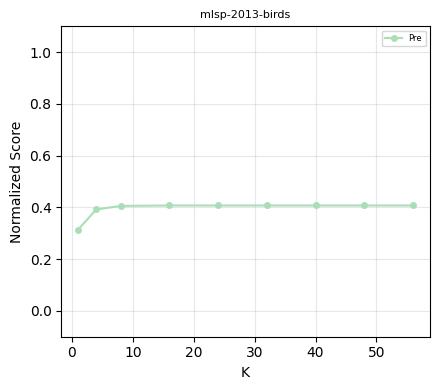

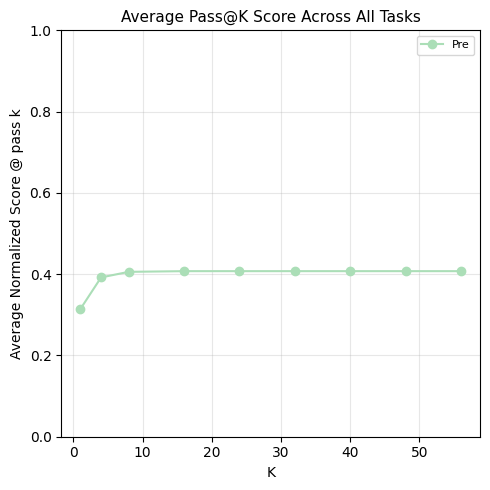

K	Pre
1	0.3139
4	0.3920
8	0.4057
16	0.4074
24	0.4074
32	0.4074
40	0.4074
48	0.4074
56	0.4074
64	nan


In [8]:
# Test pass@k for percentile scores
results_df = plot_pass_at_k(df_task, metric="percentile")

In [9]:
# Compare metrics across the full dataset
plot_metric_comparison([df_processed], labels=["New"], metric="percentile", agg="mean")


plot_metric_comparison([df_processed], labels=["New"], metric="medal", agg="mean")

Mean Percentile New: 0.3139 ± 0.0812


Mean Any Medal New: 0.0000 ± 0.0000
Mean Gold Medal New: 0.0000 ± 0.0000
Mean Silver Medal New: 0.0000 ± 0.0000
Mean Bronze Medal New: 0.0000 ± 0.0000


({'any_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'gold_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'silver_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'bronze_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]}},
 None)